In [1]:
# ==========================================
# BLOQUE 1: INSTALACIÓN E IMPORTACIÓN
# ==========================================
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os  # <-- VITAL: Librería del sistema operativo para gestionar rutas de archivos de forma segura

print(f"Versión de TensorFlow: {tf.__version__}")
print(f"GPUs disponibles: {len(tf.config.list_physical_devices('GPU'))}")

# --- DEFINICIÓN DE RUTAS (KAGGLE) ---
# Ruta raíz sacada de tu propio error en consola para asegurar compatibilidad
BASE_PATH = '/kaggle/input/datasets/mjgut05/matsynth-pbr-cleaned/matsynth_dataset'

# os.path.join une la ruta base con el nombre de la carpeta, asegurando que siempre haya un '/' en medio.
PATH_RGB = os.path.join(BASE_PATH, 'rgb')
PATH_NORMAL = os.path.join(BASE_PATH, 'normal')
PATH_ROUGHNESS = os.path.join(BASE_PATH, 'roughness')

# Dimensiones globales de los tensores para toda la arquitectura
IMG_WIDTH = 256
IMG_HEIGHT = 256

2026-04-01 19:38:52.886930: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775072333.085260      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775072333.139141      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775072333.603344      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775072333.603386      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775072333.603389      24 computation_placer.cc:177] computation placer alr

Versión de TensorFlow: 2.19.0
GPUs disponibles: 1


In [2]:
# ==========================================
# BLOQUE 2: FUNCIÓN DE CARGA Y EMPAREJAMIENTO DE TENSORES
# ==========================================
def cargar_y_emparejar(ruta_rgb):
    """
    Toma la ruta de una imagen RGB, deduce dónde están las Normales y Roughness,
    las carga a memoria y devuelve (X_entrada, Y_objetivo_concatenado).
    """
    # 1. DEDUCCIÓN DE RUTAS SECUNDARIAS
    # Separamos la ruta por las barras (/) y nos quedamos con la última parte (ej: 'textura_01.png')
    partes = tf.strings.split(ruta_rgb, os.path.sep)
    nombre_archivo = partes[-1]
    
    # Unimos las carpetas PBR correspondientes con el mismo nombre de archivo
    ruta_normal = tf.strings.join([PATH_NORMAL, os.path.sep, nombre_archivo])
    ruta_roughness = tf.strings.join([PATH_ROUGHNESS, os.path.sep, nombre_archivo])

    # 2. LECTURA RAW (Binaria) DEL DISCO DURO
    rgb_raw = tf.io.read_file(ruta_rgb)
    normal_raw = tf.io.read_file(ruta_normal)
    roughness_raw = tf.io.read_file(ruta_roughness)

    # 3. DECODIFICACIÓN Y FORZADO DE CANALES
    # channels=3 para color y relieve. channels=1 para escala de grises.
    img_rgb = tf.image.decode_png(rgb_raw, channels=3)
    img_normal = tf.image.decode_png(normal_raw, channels=3)
    img_roughness = tf.image.decode_png(roughness_raw, channels=1)

    # Convertimos los valores enteros [0-255] a números decimales (float32)
    img_rgb = tf.cast(img_rgb, tf.float32)
    img_normal = tf.cast(img_normal, tf.float32)
    img_roughness = tf.cast(img_roughness, tf.float32)

    # 4. NORMALIZACIÓN MATEMÁTICA AL RANGO [-1.0, 1.0]
    # Necesario para que coincida con la salida de la función de activación Tanh del Generador
    img_rgb = (img_rgb / 127.5) - 1.0
    img_normal = (img_normal / 127.5) - 1.0
    img_roughness = (img_roughness / 127.5) - 1.0

    # 5. STACKING (Creación del Ground Truth)
    # Pegamos el Roughness (1 canal) como una nueva "capa" detrás de la Normal (3 canales). Salida = 4 canales.
    mapas_objetivo = tf.concat([img_normal, img_roughness], axis=-1)

    return img_rgb, mapas_objetivo

In [3]:
# VERIFICACIÓN:
# Buscamos de forma segura las imágenes dentro de la carpeta rgb
patron_busqueda = os.path.join(PATH_RGB, '*.png')
archivos_test = tf.data.Dataset.list_files(patron_busqueda)

# Tomamos la primera imagen que encuentre y validamos la matemática del tensor
for ruta_prueba in archivos_test.take(1):
    print(f"Probando archivo: {ruta_prueba.numpy().decode('utf-8')}")
    
    x_test, y_test = cargar_y_emparejar(ruta_prueba)
    
    print(f"Forma de la Entrada (RGB): {x_test.shape}")
    print(f"Rango RGB: Min {tf.reduce_min(x_test):.2f}, Max {tf.reduce_max(x_test):.2f}")
    
    print(f"Forma del Objetivo (Normal + Roughness): {y_test.shape}")
    print(f"Rango Objetivo: Min {tf.reduce_min(y_test):.2f}, Max {tf.reduce_max(y_test):.2f}")

I0000 00:00:1775072357.903707      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Probando archivo: /kaggle/input/datasets/mjgut05/matsynth-pbr-cleaned/matsynth_dataset/rgb/terracotta_0202.png
Forma de la Entrada (RGB): (1024, 1024, 3)
Rango RGB: Min -0.74, Max 0.36
Forma del Objetivo (Normal + Roughness): (1024, 1024, 4)
Rango Objetivo: Min -1.00, Max 1.00


In [4]:
# ==========================================
# BLOQUE 3: FUNCIONES DE DATA AUGMENTATION VECTORIAL
# ==========================================
def random_jitter_y_augmentacion(img_rgb, mapas_objetivo):
    """
    Aplica transformaciones espaciales y de color, respetando rigurosamente
    la matemática vectorial del mapa de normales en el tensor objetivo.
    """
    # 1. JITTERING ESPACIAL (Recorte directo desde alta resolución)
    # Apilamos temporalmente (3 + 4 = 7 canales)
    imagen_apilada = tf.concat([img_rgb, mapas_objetivo], axis=-1)
    
    # Extraemos un "parche" de 256x256 directamente de la textura 1K original. 
    # Esto preserva el 100% del micro-detalle y la escala real del PBR.
    imagen_recortada = tf.image.random_crop(imagen_apilada, size=[IMG_HEIGHT, IMG_WIDTH, 7])
    
    # Volvemos a separar
    img_rgb = imagen_recortada[:, :, :3]
    mapas_objetivo = imagen_recortada[:, :, 3:]

    # 2. VOLTEO HORIZONTAL (50% de probabilidad)
    if tf.random.uniform(()) > 0.5:
        img_rgb = tf.image.flip_left_right(img_rgb)
        mapas_objetivo = tf.image.flip_left_right(mapas_objetivo)
        
        # Corrección Vectorial: Invertimos el canal X (Rojo) de la Normal.
        # mapas_objetivo tiene [R, G, B, Roughness]. El Rojo está en el índice 0.
        normal_x_invertido = -mapas_objetivo[:, :, 0:1] 
        resto_canales = mapas_objetivo[:, :, 1:] # G, B y Roughness se quedan igual
        mapas_objetivo = tf.concat([normal_x_invertido, resto_canales], axis=-1)

    # 3. VOLTEO VERTICAL (50% de probabilidad)
    if tf.random.uniform(()) > 0.5:
        img_rgb = tf.image.flip_up_down(img_rgb)
        mapas_objetivo = tf.image.flip_up_down(mapas_objetivo)
        
        # Corrección Vectorial: Invertimos el canal Y (Verde) de la Normal.
        # El Verde está en el índice 1.
        canal_rojo = mapas_objetivo[:, :, 0:1]
        normal_y_invertido = -mapas_objetivo[:, :, 1:2] 
        resto_canales = mapas_objetivo[:, :, 2:] # B y Roughness
        mapas_objetivo = tf.concat([canal_rojo, normal_y_invertido, resto_canales], axis=-1)

    # 4. ALTERACIÓN DE BRILLO (Solo al RGB)
    # Alteramos ligeramente la iluminación general de la foto de entrada (máximo +/- 10%)
    img_rgb = tf.image.random_brightness(img_rgb, max_delta=0.1)
    
    # IMPORTANTE: El cambio de brillo podría empujar valores fuera del rango [-1, 1].
    # Cortamos matemáticamente cualquier exceso.
    img_rgb = tf.clip_by_value(img_rgb, -1.0, 1.0)
    
    return img_rgb, mapas_objetivo

In [5]:
# ==========================================
# BLOQUE 4: CONSTRUCCIÓN DEL DATASET PIPELINE (tf.data)
# ==========================================
# Funciones de mapeo para el pipeline
def procesar_train(ruta):
    # Carga y empareja (Fase 1) y luego aplica Augmentation (Fase 2)
    img_rgb, mapas_objetivo = cargar_y_emparejar(ruta)
    img_rgb, mapas_objetivo = random_jitter_y_augmentacion(img_rgb, mapas_objetivo)
    return img_rgb, mapas_objetivo

def procesar_test(ruta):
    """
    Procesa las imágenes de validación/test. 
    NO aplica augmentation (ni giros, ni brillos, ni random crop) para mantener 
    la métrica de evaluación pura. Solo extrae el parche central exacto.
    """
    # 1. Carga inicial a resolución completa (ej. 1024x1024)
    # Aquí es donde nacen las variables img_rgb y mapas_objetivo
    img_rgb, mapas_objetivo = cargar_y_emparejar(ruta)
    
    # 2. Recorte Central Determinista (Central Crop)
    # Recortamos AMBOS tensores exactamente por el centro a 256x256.
    # Es vital que ambos pasen por la misma operación para no desalinear el RGB del relieve.
    img_rgb = tf.image.resize_with_crop_or_pad(img_rgb, IMG_HEIGHT, IMG_WIDTH)
    mapas_objetivo = tf.image.resize_with_crop_or_pad(mapas_objetivo, IMG_HEIGHT, IMG_WIDTH)
    
    return img_rgb, mapas_objetivo

# Obtenemos todas las rutas disponibles
patron_busqueda = os.path.join(PATH_RGB, '*.png')
dataset_rutas = tf.data.Dataset.list_files(patron_busqueda, shuffle=False)

# Barajamos las rutas antes de dividir (Semilla fija para reproducibilidad)
DATASET_SIZE = 1483
dataset_rutas = dataset_rutas.shuffle(DATASET_SIZE, seed=42)

# Split 90% Train - 10% Test
train_size = int(0.9 * DATASET_SIZE)
train_rutas = dataset_rutas.take(train_size)
test_rutas = dataset_rutas.skip(train_size)

# PARÁMETROS DE HARDWARE (Optimizados para tu P100)
BATCH_SIZE = 16  # 16 consumirá unos 6-8GB de VRAM, perfecto para acelerar el proceso
BUFFER_SIZE = 400

# Construimos el Dataset de Entrenamiento asíncrono
train_dataset = train_rutas.map(procesar_train, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Construimos el Dataset de Test asíncrono
test_dataset = test_rutas.map(procesar_test, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Dataset creado. Tamaño del lote: {BATCH_SIZE}.")
print(f"Batches por época (Aprox): {train_size // BATCH_SIZE}")

Dataset creado. Tamaño del lote: 16.
Batches por época (Aprox): 83


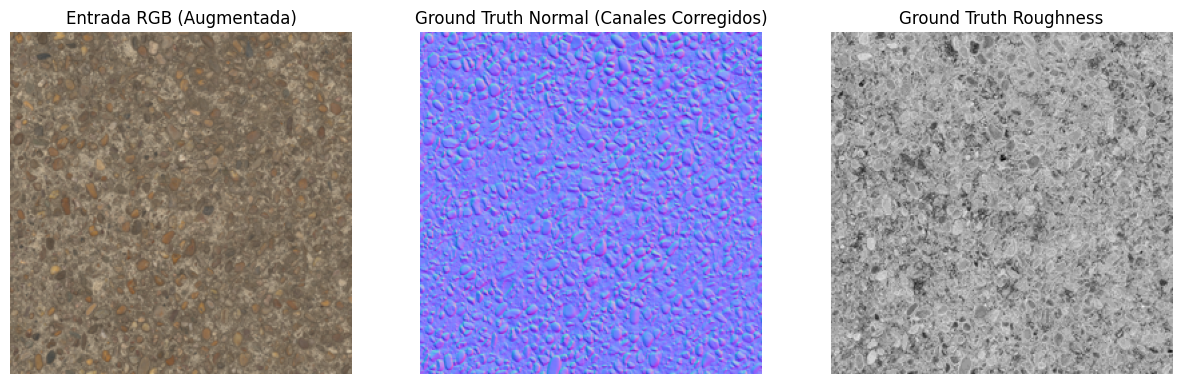

Shapes finales del batch: X=(16, 256, 256, 3), Y=(16, 256, 256, 4)


In [6]:
# VERIFICACIÓN:
# Extraemos 1 solo Batch (de 16 imágenes) del dataset de entrenamiento
for batch_x, batch_y in train_dataset.take(1):
    # Tomamos solo la primera imagen del Batch [0]
    img_entrada = batch_x[0]
    img_normal_generada = batch_y[0][:, :, :3] # Separamos los primeros 3 canales
    img_roughness_generada = batch_y[0][:, :, 3] # Separamos el canal 4 (índice 3)

    # Des-normalizamos de [-1, 1] a [0, 1] para que Matplotlib pueda pintarlo
    img_entrada_plot = (img_entrada + 1.0) / 2.0
    img_normal_plot = (img_normal_generada + 1.0) / 2.0
    img_roughness_plot = (img_roughness_generada + 1.0) / 2.0

    # Pintamos los resultados
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.title("Entrada RGB (Augmentada)")
    plt.imshow(img_entrada_plot)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Ground Truth Normal (Canales Corregidos)")
    plt.imshow(img_normal_plot)
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("Ground Truth Roughness")
    plt.imshow(img_roughness_plot, cmap='gray')
    plt.axis('off')

    plt.show()
    
    print(f"Shapes finales del batch: X={batch_x.shape}, Y={batch_y.shape}")

In [7]:
# ==========================================
# BLOQUE 5: GENERADOR (U-Net con MobileNetV2)
# ==========================================
# Definición explícita de la inicialización de pesos (Básico en GANs para evitar colapso de gradiente)
initializer = tf.random_normal_initializer(0., 0.02)
OUTPUT_CHANNELS = 4 # 3 de Normal + 1 de Roughness

def upsample(filters, size, apply_dropout=False):
    """Capa de subida personalizada con control de inicialización a bajo nivel."""
    result = tf.keras.Sequential()
    result.add(
        tf.keras.layers.Conv2DTranspose(filters, size, strides=2,
                                        padding='same',
                                        kernel_initializer=initializer,
                                        use_bias=False))
    result.add(tf.keras.layers.BatchNormalization())
    if apply_dropout:
        result.add(tf.keras.layers.Dropout(0.5))
    result.add(tf.keras.layers.ReLU())
    return result

def Generator():
    """Construcción del Grafo Computacional (DAG) del Generador."""
    # 1. ENTRADA ESTÁTICA: Desvinculación total del tf.data.Dataset
    inputs = tf.keras.layers.Input(shape=[IMG_HEIGHT, IMG_WIDTH, 3], name='input_image')

    # 2. ENCODER (MobileNetV2): Extracción de características
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=[IMG_HEIGHT, IMG_WIDTH, 3], 
        include_top=False, 
        weights='imagenet'
    )
    
    # Extraemos las activaciones intermedias para las Skip Connections
    layer_names = [
        'block_1_expand_relu',   # 128x128
        'block_3_expand_relu',   # 64x64
        'block_6_expand_relu',   # 32x32
        'block_13_expand_relu',  # 16x16
        'block_16_project',      # 8x8
    ]
    base_model_outputs = [base_model.get_layer(name).output for name in layer_names]
    
    # Empaquetamos el encoder y lo congelamos (Optimización de memoria VRAM)
    down_stack = tf.keras.Model(inputs=base_model.input, outputs=base_model_outputs, name="encoder_mobilenet")
    down_stack.trainable = False 

    # 3. DECODER: Capas de subida
    up_stack = [
        upsample(512, 3, apply_dropout=True),  # (bs, 16, 16, 512)
        upsample(256, 3, apply_dropout=True),  # (bs, 32, 32, 256)
        upsample(128, 3),                      # (bs, 64, 64, 128)
        upsample(64, 3),                       # (bs, 128, 128, 64)
    ]

    # 4. CONSTRUCCIÓN DEL GRAFO DIRIGIDO (Forward Pass)
    x = inputs
    skips = down_stack(x)
    x = skips[-1]
    skips = reversed(skips[:-1])

    for up, skip in zip(up_stack, skips):
        x = up(x)
        # Concatenación matemática en el eje de los canales
        x = tf.keras.layers.Concatenate()([x, skip])

    # 5. CAPA DE SALIDA
    last = tf.keras.layers.Conv2DTranspose(
        filters=OUTPUT_CHANNELS, # Forzamos la salida PBR de 4 canales
        kernel_size=3,
        strides=2,
        padding='same',
        kernel_initializer=initializer,
        activation='tanh'
    )
    
    x = last(x)
    return tf.keras.Model(inputs=inputs, outputs=x, name="Generador_PBR")

In [8]:
# ==========================================
# BLOQUE 6: DISCRIMINADOR (PatchGAN)
# ==========================================
def downsample(filters, size, apply_batchnorm=True):
    """Capa de bajada personalizada para el Discriminador."""
    result = tf.keras.Sequential()
    result.add(
        tf.keras.layers.Conv2D(filters, size, strides=2, padding='same',
                               kernel_initializer=initializer, use_bias=False))
    if apply_batchnorm:
        result.add(tf.keras.layers.BatchNormalization())
    result.add(tf.keras.layers.LeakyReLU())
    return result

def Discriminator():
    """Construcción del Grafo Computacional (DAG) del Discriminador."""
    # 1. ENTRADAS ESTÁTICAS SIMULTÁNEAS
    inp = tf.keras.layers.Input(shape=[IMG_HEIGHT, IMG_WIDTH, 3], name='input_image')
    tar = tf.keras.layers.Input(shape=[IMG_HEIGHT, IMG_WIDTH, 4], name='target_image')

    # 2. CONCATENACIÓN (El tensor de 7 canales que evaluará la red)
    x = tf.keras.layers.concatenate([inp, tar])

    # 3. ANÁLISIS DE PARCHES (Receptive Field)
    down1 = downsample(64, 4, False)(x)  # (bs, 128, 128, 64)
    down2 = downsample(128, 4)(down1)    # (bs, 64, 64, 128)
    down3 = downsample(256, 4)(down2)    # (bs, 32, 32, 256)

    zero_pad1 = tf.keras.layers.ZeroPadding2D()(down3) # (bs, 34, 34, 256)
    conv = tf.keras.layers.Conv2D(512, 4, strides=1,
                                  kernel_initializer=initializer,
                                  use_bias=False)(zero_pad1) # (bs, 31, 31, 512)

    batchnorm1 = tf.keras.layers.BatchNormalization()(conv)
    leaky_relu = tf.keras.layers.LeakyReLU()(batchnorm1)
    zero_pad2 = tf.keras.layers.ZeroPadding2D()(leaky_relu) # (bs, 33, 33, 512)

    # Capa de decisión (Mapa de probabilidad)
    last = tf.keras.layers.Conv2D(1, 4, strides=1,
                                  kernel_initializer=initializer)(zero_pad2) # (bs, 30, 30, 1)

    return tf.keras.Model(inputs=[inp, tar], outputs=last, name="Discriminador_PatchGAN")

In [9]:
# VERIFICACIONES:
generador = Generator() 
discriminador = Discriminator() 

# Verificamos los tensores con ruido blanco
ruido_entrada_rgb = tf.random.normal([1, 256, 256, 3])
ruido_objetivo_pbr = tf.random.normal([1, 256, 256, 4])

prediccion_pbr = generador(ruido_entrada_rgb, training=False)
decision_discriminador = discriminador([ruido_entrada_rgb, prediccion_pbr], training=False)

print(f"Salida del Generador: {prediccion_pbr.shape} -> Debería ser (1, 256, 256, 4)")
print(f"Salida del Discriminador: {decision_discriminador.shape} -> Debería ser (1, 30, 30, 1)")

print("\n--- RESUMEN DE PARÁMETROS DEL GENERADOR ---")
generador.summary()

/tmp/ipykernel_24/2699749704.py:28: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


I0000 00:00:1775072389.538101      24 cuda_dnn.cc:529] Loaded cuDNN version 91002


Salida del Generador: (1, 256, 256, 4) -> Debería ser (1, 256, 256, 4)
Salida del Discriminador: (1, 30, 30, 1) -> Debería ser (1, 30, 30, 1)

--- RESUMEN DE PARÁMETROS DEL GENERADOR ---


Model: "Generador_PBR"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_mobilenet   │ [(None, 128, 128, │  1,841,984 │ input_image[0][0] │
│ (Functional)        │ 96), (None, 64,   │            │                   │
│                     │ 64, 144), (None,  │            │                   │
│                     │ 32, 32, 192),     │            │                   │
│                     │ (None, 16, 16,    │            │                   │
│                     │ 576), (None, 8,   │            │                   │
│                     │ 8, 320)]          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 16, 16,    │  1,476,608 │ encoder_mobilene… │
│ (Sequential)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ sequential[0][0], │
│ (Concatenate)       │ 1088)             │            │ encoder_mobilene… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 32, 32,    │  2,507,776 │ concatenate[0][0] │
│ (Sequential)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 32, 32,    │          0 │ sequential_1[0][… │
│ (Concatenate)       │ 448)              │            │ encoder_mobilene… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 64, 64,    │    516,608 │ concatenate_1[0]… │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 64, 64,    │          0 │ sequential_2[0][… │
│ (Concatenate)       │ 272)              │            │ encoder_mobilene… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_3        │ (None, 128, 128,  │    156,928 │ concatenate_2[0]… │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 128, 128,  │          0 │ sequential_3[0][… │
│ (Concatenate)       │ 160)              │            │ encoder_mobilene… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 256, 256,  │      5,764 │ concatenate_3[0]… │
│ (Conv2DTranspose)   │ 4)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,505,668 (24.82 MB)

 Trainable params: 4,661,764 (17.78 MB)

 Non-trainable params: 1,843,904 (7.03 MB)

In [10]:
# ==========================================
# BLOQUE 7: FUNCIONES DE PÉRDIDA Y OPTIMIZADORES
# ==========================================
# 1. Optimizadores (Adam con beta_1=0.5 es el estándar de oro empírico para GANs)
generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

# 2. Objeto base para calcular entropía cruzada
loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)

# Ponderación de la pérdida L1 (Qué tanto importa que el píxel sea idéntico a la realidad)
LAMBDA = 100 

def discriminator_loss(disc_real_output, disc_generated_output):
    """Calcula el error del Discriminador."""
    real_loss = loss_object(tf.ones_like(disc_real_output), disc_real_output)
    generated_loss = loss_object(tf.zeros_like(disc_generated_output), disc_generated_output)
    total_disc_loss = real_loss + generated_loss
    return total_disc_loss

def generator_loss(disc_generated_output, gen_output, target):
    """Calcula el error del Generador (Engaño + Precisión Píxel a Píxel)."""
    # Adversarial Loss: ¿Logró engañar al discriminador?
    gan_loss = loss_object(tf.ones_like(disc_generated_output), disc_generated_output)
    
    # L1 Loss: Distancia absoluta (MAE) entre el mapa generado y el real
    l1_loss = tf.reduce_mean(tf.abs(target - gen_output))
    
    total_gen_loss = gan_loss + (LAMBDA * l1_loss)
    return total_gen_loss

In [11]:
# ==========================================
# BLOQUE 8: MOTOR DE ENTRENAMIENTO (CUSTOM LOOP)
# ==========================================
@tf.function # <-- CRÍTICO: Compila esta función en un grafo de C++ para máxima velocidad
def train_step(input_image, target, epoch):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # 1. Forward Pass
        gen_output = generador(input_image, training=True)

        disc_real_output = discriminador([input_image, target], training=True)
        disc_generated_output = discriminador([input_image, gen_output], training=True)

        # 2. Cálculo de Pérdidas
        gen_total_loss = generator_loss(disc_generated_output, gen_output, target)
        disc_loss = discriminator_loss(disc_real_output, disc_generated_output)

    # 3. Cálculo de Gradientes (Backpropagation)
    generator_gradients = gen_tape.gradient(gen_total_loss, generador.trainable_variables)
    discriminator_gradients = disc_tape.gradient(disc_loss, discriminador.trainable_variables)

    # 4. Actualización de Pesos
    generator_optimizer.apply_gradients(zip(generator_gradients, generador.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(discriminator_gradients, discriminador.trainable_variables))
    
    return gen_total_loss, disc_loss

In [12]:
# ==========================================
# BLOQUE 9: TELEMETRÍA VISUAL (VERSIÓN ALTA CALIDAD)
# ==========================================
from IPython import display

# --- NUEVO: Crear carpetas para las texturas puras ---
os.makedirs('/kaggle/working/Normales_Puras', exist_ok=True)
os.makedirs('/kaggle/working/Roughness_Puras', exist_ok=True)

def generar_imagenes_progreso(modelo, test_input, tar, epoca):
    prediccion = modelo(test_input, training=False)
    
    entrada = test_input[0]
    real_normal = tar[0][:, :, :3]
    real_rough = tar[0][:, :, 3]
    pred_normal = prediccion[0][:, :, :3]
    pred_rough = prediccion[0][:, :, 3]

    # --- 1. GUARDADO DE LA COMPARATIVA VISUAL (Alta resolución DPI) ---
    imagenes = [
        (entrada + 1.0) / 2.0, 
        (real_normal + 1.0) / 2.0, 
        (pred_normal + 1.0) / 2.0,
        (real_rough + 1.0) / 2.0,
        (pred_rough + 1.0) / 2.0
    ]
    
    titulos = ['Entrada RGB', 'Normal Real', 'Normal Predicha', 'Roughness Real', 'Roughness Predicho']
    
    plt.figure(figsize=(20, 8))
    for i in range(5):
        plt.subplot(1, 5, i+1)
        plt.title(titulos[i])
        if i >= 3:
            plt.imshow(imagenes[i], cmap='gray')
        else:
            plt.imshow(imagenes[i])
        plt.axis('off')
    
    # Usamos dpi=300 para que la imagen larga tenga mucha más resolución
    ruta_imagen = f'/kaggle/working/progreso_epoca_{epoca}.png'
    plt.savefig(ruta_imagen, bbox_inches='tight', dpi=300)
    plt.show() 
    plt.close()

    # --- 2. NUEVO: GUARDADO DE TEXTURAS PURAS (Listas para Motor 3D) ---
    # Des-normalizamos de [-1, 1] al rango [0, 255] que usan las imágenes reales
    img_normal_export = tf.cast((pred_normal + 1.0) * 127.5, tf.uint8)
    img_rough_export = tf.cast((pred_rough + 1.0) * 127.5, tf.uint8)
    
    # Expandimos dimensiones del roughness para que tenga canal de "color" (escala de grises)
    img_rough_export = tf.expand_dims(img_rough_export, axis=-1)

    ruta_normal_pura = f'/kaggle/working/Normales_Puras/normal_ep_{epoca}.png'
    ruta_rough_pura = f'/kaggle/working/Roughness_Puras/rough_ep_{epoca}.png'

    tf.io.write_file(ruta_normal_pura, tf.image.encode_png(img_normal_export))
    tf.io.write_file(ruta_rough_pura, tf.image.encode_png(img_rough_export))
    
    print(f"Texturas puras de 256x256 exportadas en la época {epoca}")

In [13]:
# ==========================================
# BLOQUE 9.5: TRASLADO DE PESOS PREVIOS (RESUME TRAINING)
# ==========================================
import shutil

# ATENCIÓN: Debes cambiar 'NOMBRE_DE_TU_CUADERNO' por el nombre real de la carpeta 
# que aparece en Kaggle dentro de la ruta /kaggle/input/
ruta_input_ckpt = '/kaggle/input/notebooks/mjgut05/pix2pix/entrenamiento_pbr'
ruta_working_ckpt = '/kaggle/working/entrenamiento_pbr'

# Si el entorno está limpio (nuevo Submit) y tenemos pesos previos cargados en input...
if os.path.exists(ruta_input_ckpt) and not os.path.exists(ruta_working_ckpt):
    print("Detectados pesos de un entrenamiento anterior. Copiando a entorno de trabajo...")
    shutil.copytree(ruta_input_ckpt, ruta_working_ckpt)
    print("¡Copia completada con éxito!")
else:
    print("No se requiere copia previa o la carpeta ya existe.")

Detectados pesos de un entrenamiento anterior. Copiando a entorno de trabajo...
¡Copia completada con éxito!


In [14]:
# ==========================================
# BLOQUE 9.8: INYECCIÓN DE FINE-TUNING (ÉPOCAS 101+)
# ==========================================
print("Activando Fase de Fine-Tuning Avanzado...")

# 1. Descongelamos el "cerebro" (Encoder MobileNetV2)
encoder = generador.get_layer("encoder_mobilenet")
encoder.trainable = True

# 2. Reducimos los reflejos de aprendizaje (Learning Rate) a la décima parte
# Esto permite que la red aprenda micro-detalles sin "olvidar" la macro-estructura
generator_optimizer.learning_rate.assign(2e-5)
discriminator_optimizer.learning_rate.assign(2e-5)

print(f"Estado del Encoder: Trainable = {encoder.trainable}")
print("Learning Rates ajustados a 2e-5. ¡Listos para micro-relieves!")

Activando Fase de Fine-Tuning Avanzado...
Estado del Encoder: Trainable = True
Learning Rates ajustados a 2e-5. ¡Listos para micro-relieves!


In [15]:
# ==========================================
# BLOQUE 10: CHECKPOINTS Y BUCLE PRINCIPAL
# ==========================================
import time

# 1. Configuración de Checkpoints
# Empaquetamos todo el estado del entrenamiento (Modelos + Optimizadores)
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generador=generador,
                                 discriminador=discriminador)

# Le decimos dónde guardar y cuántos archivos mantener simultáneamente
checkpoint_dir = '/kaggle/working/entrenamiento_pbr'
manager = tf.train.CheckpointManager(checkpoint, checkpoint_dir, max_to_keep=2)

# (Opcional) Restaurar si el cuaderno se cortó a la mitad
if manager.latest_checkpoint:
    checkpoint.restore(manager.latest_checkpoint)
    print(f"Restaurado desde el checkpoint: {manager.latest_checkpoint}")

# 2. El Motor de Entrenamiento
def entrenar_modelo(dataset_entrenamiento, dataset_prueba, epocas):
    # Extraemos un batch fijo de prueba para ver siempre cómo evoluciona la MISMA imagen
    for batch_prueba_x, batch_prueba_y in dataset_prueba.take(1):
        ejemplo_x, ejemplo_y = batch_prueba_x, batch_prueba_y

    desfase_epocas = 100 # Cambiaremos esto a 150 en la siguiente tanda
    for epoca in range(epocas):
        epoca_real = epoca + desfase_epocas        
        
        inicio = time.time()

        print(f"\nIniciando Época {epoca_real + 1} (Tanda Actual: {epoca + 1}/{epocas})")
        
        # Iteramos sobre los batches
        contador = 0
        for image_batch, target_batch in dataset_entrenamiento:
            # Invocamos la función @tf.function compilada en el Bloque 8
            loss_g, loss_d = train_step(image_batch, target_batch, epoca)
            
            contador += 1
            # Imprimimos progreso sin saltar de línea para mantener limpia la consola
            print(f"\rBatch {contador} procesado. Loss G: {loss_g:.4f} | Loss D: {loss_d:.4f}", end="")

        # Limpiamos la consola de Kaggle
        display.clear_output(wait=True)
        
        # Mostramos y GUARDAMOS cómo va el aprendizaje (Le pasamos epoca + 1)
        generar_imagenes_progreso(generador, ejemplo_x, ejemplo_y, epoca_real + 1)

        # Guardamos un Checkpoint cada 5 épocas
        if (epoca_real + 1) % 5 == 0:
            ruta = manager.save()
            print(f"Checkpoint guardado en: {ruta}")

        tiempo_epoca = time.time() - inicio
        print(f"Época {epoca_real + 1} completada en {tiempo_epoca:.0f} segundos.")

Restaurado desde el checkpoint: /kaggle/working/entrenamiento_pbr/ckpt-20


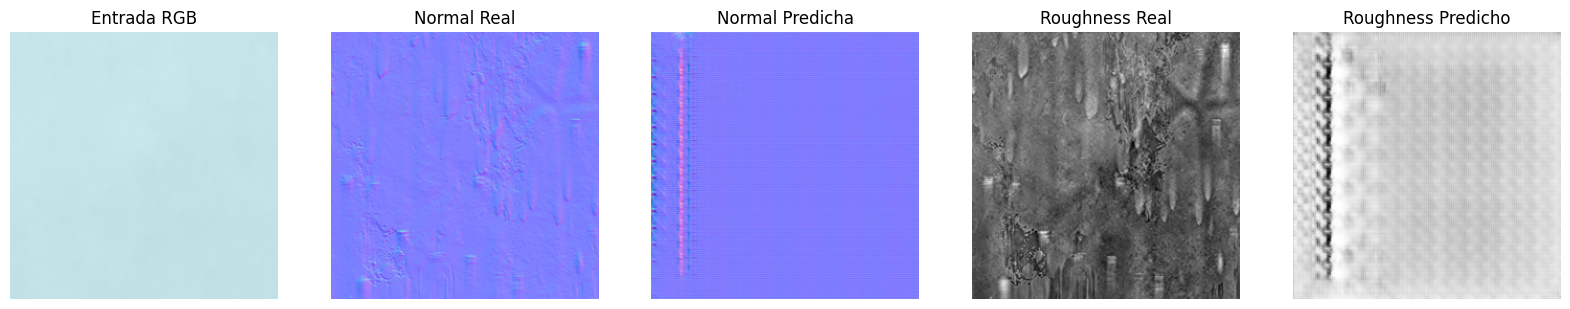

Texturas puras de 256x256 exportadas en la época 150
Checkpoint guardado en: /kaggle/working/entrenamiento_pbr/ckpt-30
Época 150 completada en 95 segundos.


In [16]:
# ==========================================
# EJECUCIÓN MAESTRA (Fase de Producción)
# ==========================================
TOTAL_EPOCAS = 50 
entrenar_modelo(train_dataset, test_dataset, TOTAL_EPOCAS)